#Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

#Load Dataset

In [2]:
df = pd.read_csv(
    "/content/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.shape)

(2640, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
df.duplicated().sum()

np.int64(0)

#EDA
##Deliveries Trend

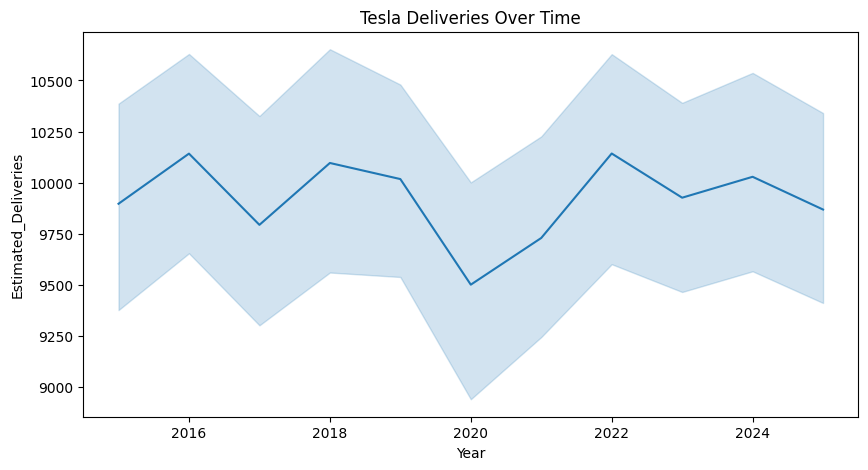

In [8]:
plt.figure(figsize=(10,5))

sns.lineplot(data=df,x="Year",y="Estimated_Deliveries")

plt.title("Tesla Deliveries Over Time")
plt.show()

##Production vs Deliveries

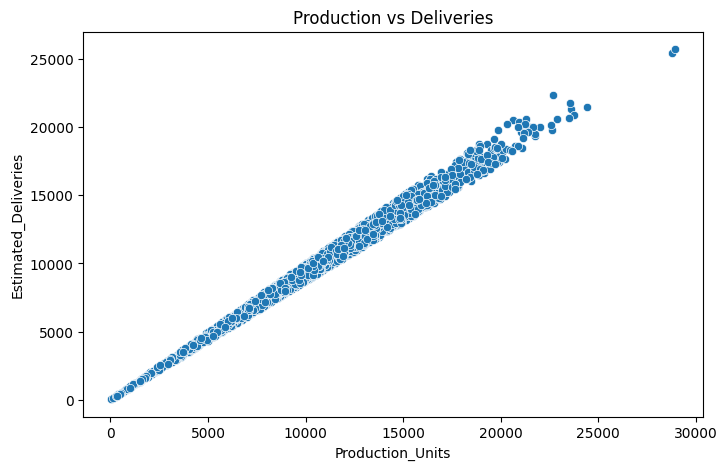

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="Production_Units",y="Estimated_Deliveries")

plt.title("Production vs Deliveries")
plt.show()

##Correlation Heatmap

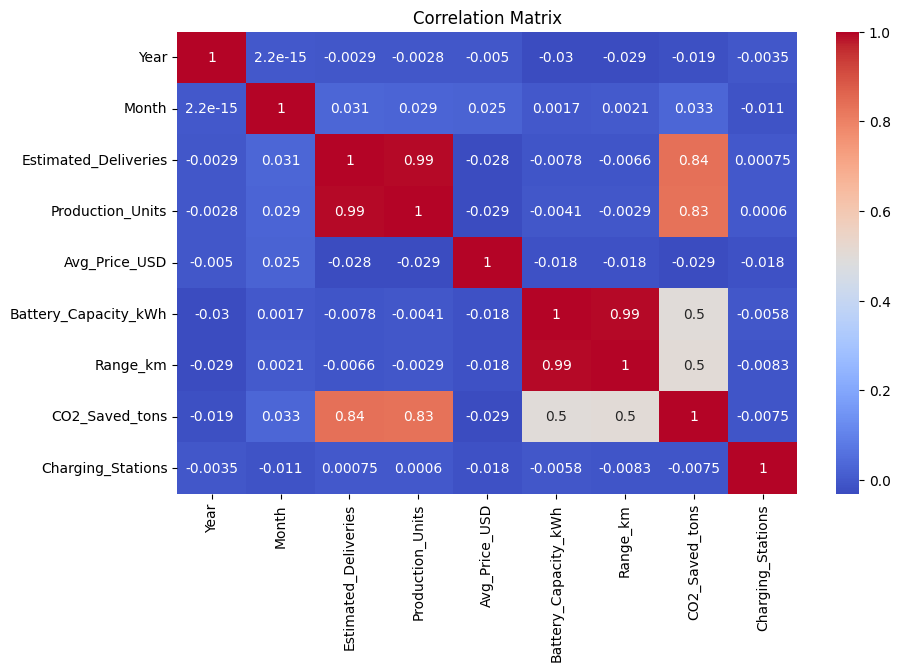

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

##Deliveries by Region

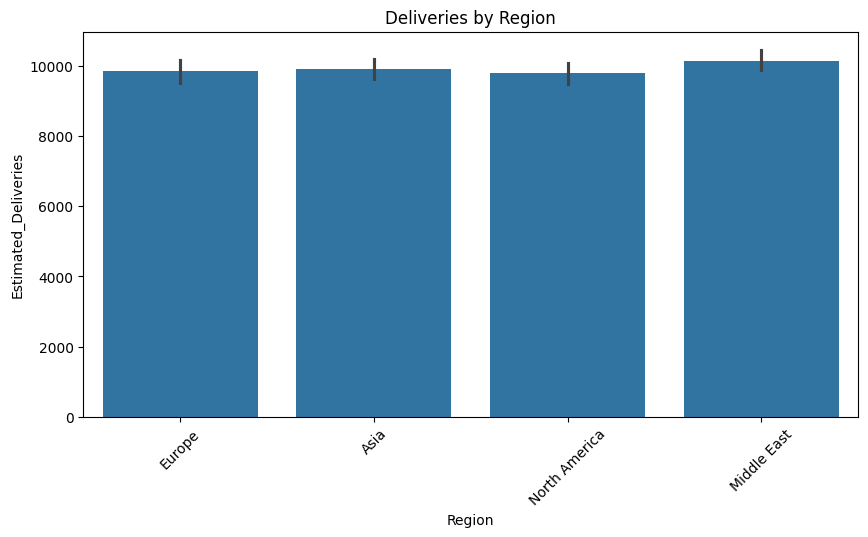

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(data=df,x="Region",y="Estimated_Deliveries")

plt.xticks(rotation=45)

plt.title("Deliveries by Region")

plt.show()

#Feature Engineering

In [12]:
df["Date"] = pd.to_datetime(df["Year"].astype(str)+ "-"+ df["Month"].astype(str))

In [13]:
df = df.sort_values("Date")

In [14]:
df["Prev_Deliveries"] = (df["Estimated_Deliveries"].shift(1))

In [15]:
df["Prev_Deliveries"] = (df["Prev_Deliveries"].fillna(df["Prev_Deliveries"].median()))

#Train-Test Split

In [16]:
X = df.drop(["Estimated_Deliveries","Date"],axis=1)

y = df["Estimated_Deliveries"]

In [17]:
#Categorical Columns

cat_cols = ["Region","Model","Source_Type"]

In [18]:
#Numerical Columns

num_cols = [col for col in X.columns if col not in cat_cols]

In [19]:
preprocessor = ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),
            cat_cols)],remainder="passthrough")

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Linear Regression

In [21]:
lr= Pipeline([("prep",preprocessor),("model",LinearRegression())])

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [22]:
print("MAE:",mean_absolute_error(y_test,lr_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,lr_pred)))

print("R2:",r2_score(y_test,lr_pred))

MAE: 312.3540697188791
RMSE: 382.2014451911557
R2: 0.9902502603452525


#Random Forest

In [23]:
rf= Pipeline([("prep",preprocessor),("model",RandomForestRegressor(random_state=42))])

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

#Hyperparameter Tuning

In [24]:
param_grid = {"model__n_estimators":[100,200],"model__max_depth":[5,10,None]}

In [25]:
grid = GridSearchCV(rf,param_grid,cv=3,scoring="r2")

grid.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'model__max_depth': [5, 10, None],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [26]:
print(grid.best_params_)

best_model = grid.best_estimator_

{'model__max_depth': None, 'model__n_estimators': 200}


#Tuned Model Evaluation

In [27]:
pred = best_model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))

print("R2:",r2_score(y_test,pred))

MAE: 304.5364962121212
RMSE: 392.7825482521574
R2: 0.9897029520301087


#Time Series Forecasting

In [28]:
#Monthly Deliveries

ts = (df.groupby("Date")["Estimated_Deliveries"].sum())

##ARIMA

In [35]:
model = ARIMA(ts,order=(3,1,2))

arima = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
#Forecast Next 12 Months

forecast = arima.forecast(steps=12)

print(forecast)

2026-01-01    197781.483031
2026-02-01    201017.032282
2026-03-01    195865.343364
2026-04-01    198228.674865
2026-05-01    195001.733366
2026-06-01    197035.944164
2026-07-01    194758.258915
2026-08-01    196445.131731
2026-09-01    194760.792317
2026-10-01    196115.750843
2026-11-01    194842.128626
2026-12-01    195911.735046
Freq: MS, Name: predicted_mean, dtype: float64


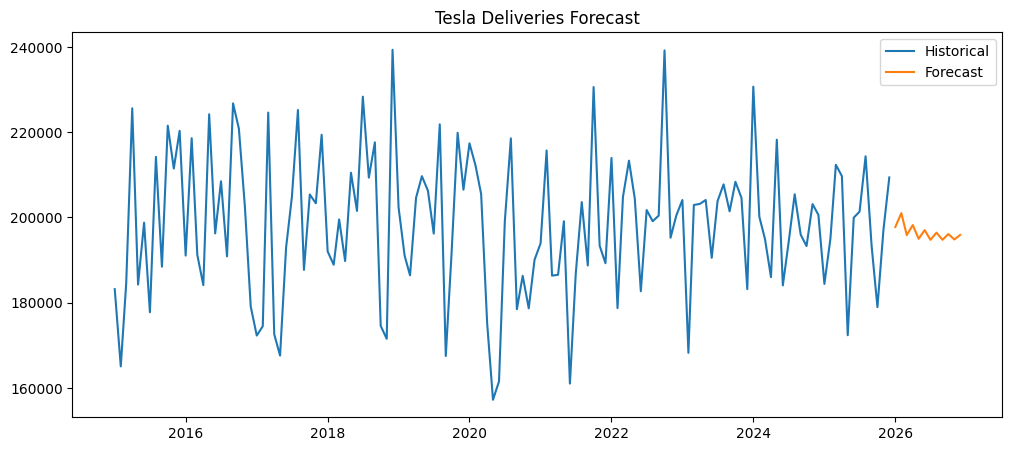

In [37]:
plt.figure(figsize=(12,5))

plt.plot(ts,label="Historical")

plt.plot(forecast.index,forecast.values,label="Forecast")

plt.legend()

plt.title("Tesla Deliveries Forecast")

plt.show()

In this project, I built an end-to-end machine learning pipeline using Tesla delivery and production data from 2015 to 2025. I cleaned the dataset, explored it using different visualizations, and created useful features for model training. I trained both Linear Regression and Random Forest models to predict estimated deliveries and compared their performance. Linear Regression performed slightly better with an R² score of about 99%, showing that it was able to predict deliveries very accurately. Finally, I used the ARIMA model to forecast future deliveries. The forecast suggests that Tesla deliveries are expected to remain fairly stable with small fluctuations in the coming months. Overall, this project helped me understand the complete machine learning workflow, from data preprocessing to prediction and forecasting.
